# UK demand flow map (recreated)

This notebook recreates a demand flow map for the UK dataset, using a style similar to the Korea map.

cwd: c:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt
base: c:\Users\Minji Kang\Documents\GitHub\railnet_opt\01_data\korea
[demand_03] type=dict
  keys(195): ['경부고속철도1_1', '경부고속철도1_2', '경부고속철도1_3', '경부고속철도1_4', '경부고속철도1_5', '경부고속철도1_6', '경부고속철도1_7', '경부고속철도1_8']
  sample key: 경부고속철도1_1

[nodes] type=dict
  keys(79): ['n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8']
  sample key: n1
  sample value keys: ['x', 'y']

[edges] type=dict
  keys(192): ['e1', 'e1r', 'e2', 'e2r', 'e3', 'e3r', 'e4', 'e4r']
  sample key: e1
  sample value keys: ['from', 'to', 'tau', 'arc_distance', 'intact_capacity', 'probs']

[routes_nodes] type=dict
  keys(105): ['경부고속철도1_1', '경부고속철도1_2', '경부고속철도1_3', '경부고속철도1_4', '경부고속철도1_5', '경부고속철도1_6', '경부고속철도1_7', '경부고속철도1_8']
  sample key: 경부고속철도1_1

node_xy: 79 nodes, missing coords: 0
edge_uv: 192 edges
edge_list_mode: True, edge_pairs: 12426
demands processed: 12426
route legs: 12426, matched: 2060, unmatched: 10366
saved: c:\Users\Minji K

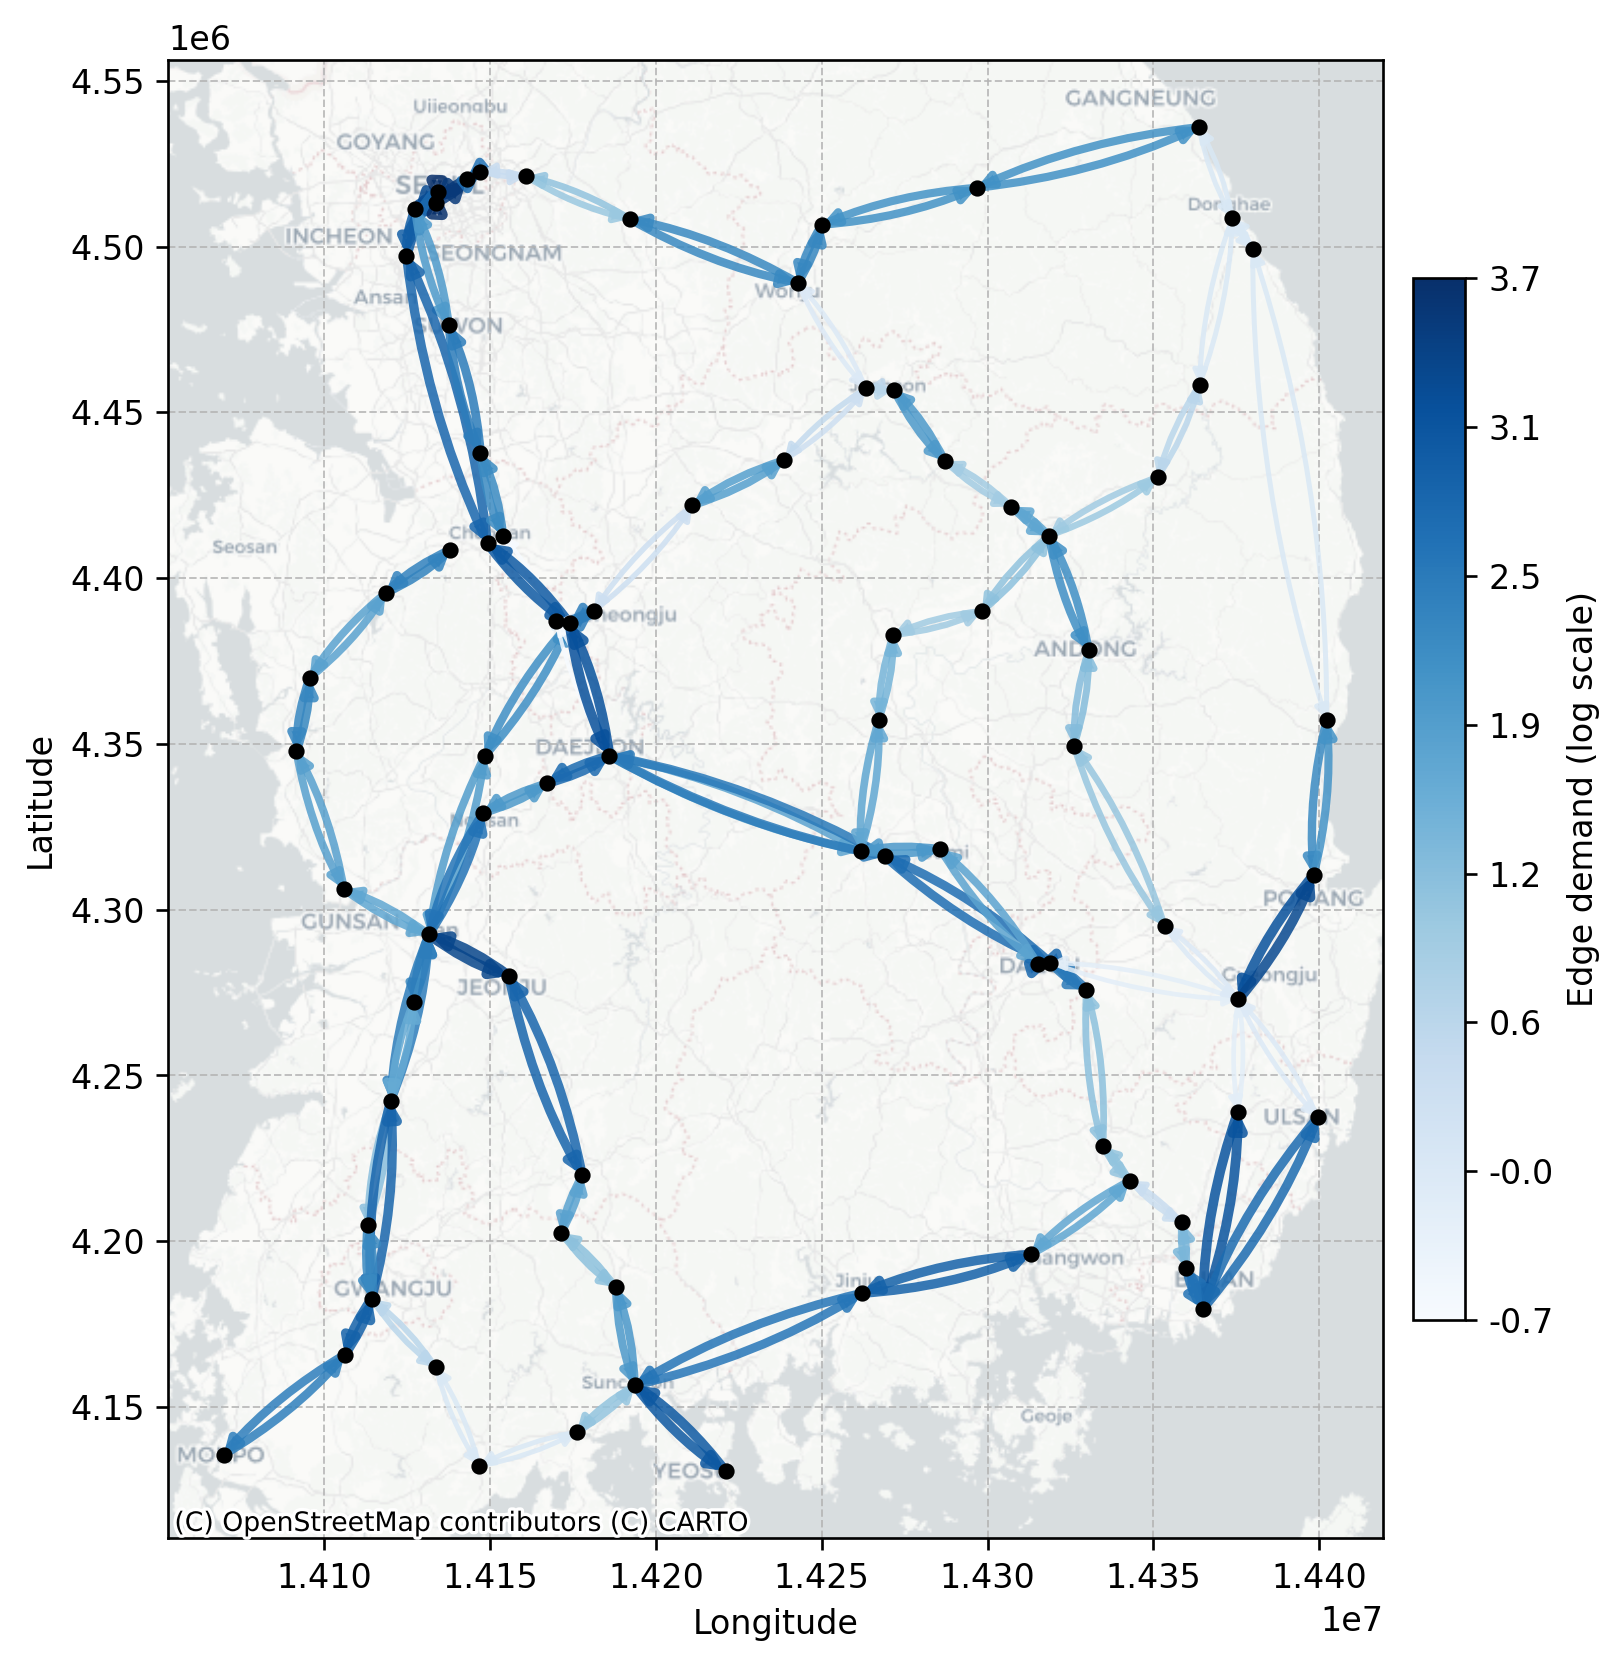

In [8]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch
import contextily as ctx

# --- File paths ---
ROOT = Path.cwd()
if not (ROOT / '01_data').exists():
    for p in [ROOT.parent, *ROOT.parents]:
        if (p / '01_data').exists():
            ROOT = p
            break

BASE = ROOT / '01_data' / 'korea'
print(f'cwd: {Path.cwd()}')
print(f'base: {BASE}')

demand_path = BASE / 'demand_03.json'
nodes_path = BASE / 'nodes.json'
edges_path = BASE / 'edges.json'
routes_path = BASE / 'routes_nodes.json'
out_path = BASE / 'demand_map_03.png'

def summarize_json(label, obj):
    print(f"[{label}] type={type(obj).__name__}")
    if isinstance(obj, dict):
        keys = list(obj.keys())
        print(f"  keys({len(keys)}): {keys[:8]}")
        if keys:
            first = obj[keys[0]]
            print(f"  sample key: {keys[0]}")
            if isinstance(first, dict):
                print(f"  sample value keys: {list(first.keys())[:8]}")
    elif isinstance(obj, list):
        print(f"  length: {len(obj)}")
        if obj:
            first = obj[0]
            print(f"  first elem type: {type(first).__name__}")
            if isinstance(first, dict):
                print(f"  first elem keys: {list(first.keys())[:8]}")
    print()

# --- Load JSON with compact schema summaries ---
demand_j = json.loads(demand_path.read_text(encoding="utf-8"))
summarize_json("demand_03", demand_j)

nodes_j = json.loads(nodes_path.read_text(encoding="utf-8"))
summarize_json("nodes", nodes_j)

edges_j = json.loads(edges_path.read_text(encoding="utf-8"))
summarize_json("edges", edges_j)

routes_j = json.loads(routes_path.read_text(encoding="utf-8"))
summarize_json("routes_nodes", routes_j)

# --- Build lookups ---
# nodes.json can be list or dict; normalize to dict of id -> {x,y}
if isinstance(nodes_j, list):
    node_dict = {str(n.get("id") or n.get("node_id") or n.get("node") or n.get("name")): n for n in nodes_j}
else:
    node_dict = {str(k): v for k, v in nodes_j.items()}

def pick_xy(n):
    for kx, ky in [("x","y"),("lon","lat"),("lng","lat"),("longitude","latitude")]:
        if kx in n and ky in n:
            return float(n[kx]), float(n[ky])
    # fallback: if geometry field exists like "pos" or "coord"
    for k in ["pos","coord","coords","xy"]:
        if k in n and isinstance(n[k], (list, tuple)) and len(n[k]) >= 2:
            return float(n[k][0]), float(n[k][1])
    return None

node_xy = {}
missing_xy = 0
for nid, n in node_dict.items():
    xy = pick_xy(n) if isinstance(n, dict) else None
    if xy is None:
        missing_xy += 1
        continue
    node_xy[str(nid)] = xy
print(f"node_xy: {len(node_xy)} nodes, missing coords: {missing_xy}")

# edges.json can be list or dict; normalize to dict of id -> {u,v}
if isinstance(edges_j, list):
    edge_dict = {str(e.get("id") or e.get("edge_id") or e.get("eid") or e.get("name")): e for e in edges_j}
else:
    edge_dict = {str(k): v for k, v in edges_j.items()}

def pick_uv(e):
    for ku, kv in [("u","v"),("from","to"),("source","target"),("start","end")]:
        if ku in e and kv in e:
            return str(e[ku]), str(e[kv])
    return None

edge_uv = {}
uv_to_eid = {}
uv_to_eid_rev = {}
for eid, e in edge_dict.items():
    if isinstance(e, dict):
        uv = pick_uv(e)
        if uv:
            u, v = uv
            edge_uv[str(eid)] = (u, v)
            uv_to_eid[(u, v)] = str(eid)
            uv_to_eid_rev[(v, u)] = str(eid)
print(f"edge_uv: {len(edge_uv)} edges")

# --- Parse demand ---
# --- Parse demand ---
# demand_03.json may be:
# 1) dict: id -> list of [u, v, q]
# 2) list of records with id + q and routes_nodes.json provides path

def infer_demand_records(dj):
    if isinstance(dj, dict):
        # if dict of id->record
        if all(isinstance(v, dict) for v in dj.values()):
            return [(str(k), v) for k, v in dj.items()]
        # if dict with a list key
        for k in ["demand","demands","records","data","items"]:
            if k in dj and isinstance(dj[k], list):
                return [(str(i), r) for i, r in enumerate(dj[k])]
    if isinstance(dj, list):
        return [(str(i), r) for i, r in enumerate(dj)]
    return []

def extract_edge_pairs(dj):
    pairs = []
    if isinstance(dj, dict):
        for k, lst in dj.items():
            if isinstance(lst, list):
                for rec in lst:
                    if isinstance(rec, (list, tuple)) and len(rec) >= 3:
                        try:
                            pairs.append((str(rec[0]), str(rec[1]), float(rec[2])))
                        except Exception:
                            pass
                    elif isinstance(rec, dict):
                        # try dict keys
                        u = rec.get('u') or rec.get('from') or rec.get('source')
                        v = rec.get('v') or rec.get('to') or rec.get('target')
                        q = rec.get('q') or rec.get('demand') or rec.get('flow') or rec.get('value')
                        if u is not None and v is not None and q is not None:
                            try:
                                pairs.append((str(u), str(v), float(q)))
                            except Exception:
                                pass
    elif isinstance(dj, list):
        for rec in dj:
            if isinstance(rec, (list, tuple)) and len(rec) >= 3:
                try:
                    pairs.append((str(rec[0]), str(rec[1]), float(rec[2])))
                except Exception:
                    pass
            elif isinstance(rec, dict):
                u = rec.get('u') or rec.get('from') or rec.get('source')
                v = rec.get('v') or rec.get('to') or rec.get('target')
                q = rec.get('q') or rec.get('demand') or rec.get('flow') or rec.get('value')
                if u is not None and v is not None and q is not None:
                    try:
                        pairs.append((str(u), str(v), float(q)))
                    except Exception:
                        pass
    return pairs

edge_pairs = extract_edge_pairs(demand_j)
edge_list_mode = len(edge_pairs) > 0
print(f"edge_list_mode: {edge_list_mode}, edge_pairs: {len(edge_pairs)}")

if not edge_list_mode:
    demand_records = infer_demand_records(demand_j)
    print(f"demand_records: {len(demand_records)}")

    def pick_demand_id(rec):
        for k in ["train_id","service_id","route_id","id","rid","name"]:
            if k in rec:
                return str(rec[k])
        return None

    def pick_demand_value(rec):
        for k in ["q","demand","passengers","flow","volume","value"]:
            if k in rec:
                try:
                    return float(rec[k])
                except Exception:
                    pass
        return None

# --- Parse routes nodes ---
if not edge_list_mode:
    def infer_routes_dict(rj):
        if isinstance(rj, dict):
            # dict of id -> list
            if all(isinstance(v, list) for v in rj.values()):
                return {str(k): v for k, v in rj.items()}
            # nested dict with list under key
            for k in ["routes","paths","data","items"]:
                if k in rj and isinstance(rj[k], dict):
                    # expects id -> list inside
                    return {str(kk): vv for kk, vv in rj[k].items()}
                if k in rj and isinstance(rj[k], list):
                    # list of records with id + nodes
                    out = {}
                    for rec in rj[k]:
                        if not isinstance(rec, dict):
                            continue
                        rid = None
                        for rk in ["train_id","service_id","route_id","id","rid","name"]:
                            if rk in rec:
                                rid = str(rec[rk])
                                break
                        nodes = None
                        for nk in ["nodes","path","route","sequence"]:
                            if nk in rec and isinstance(rec[nk], list):
                                nodes = rec[nk]
                                break
                        if rid and nodes:
                            out[rid] = nodes
                    if out:
                        return out
        if isinstance(rj, list):
            out = {}
            for rec in rj:
                if not isinstance(rec, dict):
                    continue
                rid = None
                for rk in ["train_id","service_id","route_id","id","rid","name"]:
                    if rk in rec:
                        rid = str(rec[rk])
                        break
                nodes = None
                for nk in ["nodes","path","route","sequence"]:
                    if nk in rec and isinstance(rec[nk], list):
                        nodes = rec[nk]
                        break
                if rid and nodes:
                    out[rid] = nodes
            if out:
                return out
        return {}

    routes_dict = infer_routes_dict(routes_j)
    print(f"routes_dict: {len(routes_dict)}")

# --- Accumulate edge flows ---
edge_flow = {eid: 0.0 for eid in edge_uv.keys()}

total_demands = 0
total_legs = 0
matched_legs = 0
unmatched_legs = 0

if edge_list_mode:
    for u, v, dem in edge_pairs:
        total_demands += 1
        total_legs += 1
        eid = uv_to_eid.get((u, v)) or uv_to_eid_rev.get((u, v))
        if eid is None:
            unmatched_legs += 1
            continue
        matched_legs += 1
        edge_flow[eid] = edge_flow.get(eid, 0.0) + dem
else:
    for _, rec in demand_records:
        if not isinstance(rec, dict):
            continue
        rid = pick_demand_id(rec)
        dem = pick_demand_value(rec)
        if rid is None or dem is None:
            continue
        route_nodes = routes_dict.get(rid)
        if route_nodes is None:
            continue
        route_nodes = [str(n) for n in route_nodes]
        total_demands += 1
        for a, b in zip(route_nodes[:-1], route_nodes[1:]):
            total_legs += 1
            eid = uv_to_eid.get((a, b)) or uv_to_eid_rev.get((a, b))
            if eid is None:
                unmatched_legs += 1
                continue
            matched_legs += 1
            edge_flow[eid] = edge_flow.get(eid, 0.0) + dem

print(f"demands processed: {total_demands}")
print(f"route legs: {total_legs}, matched: {matched_legs}, unmatched: {unmatched_legs}")

# --- Prepare plot ---
# detect lon/lat and project to EPSG:3857 if needed (for contextily basemap)
xs_raw = [xy[0] for xy in node_xy.values()]
ys_raw = [xy[1] for xy in node_xy.values()]

if xs_raw and ys_raw:
    max_abs_x = max(abs(x) for x in xs_raw)
    max_abs_y = max(abs(y) for y in ys_raw)
else:
    max_abs_x = max_abs_y = 0.0

is_lonlat = (max_abs_x <= 180.5) and (max_abs_y <= 90.5)

def lonlat_to_3857(lon, lat):
    # Web Mercator projection formula
    r = 6378137.0
    lat = max(min(lat, 85.05112878), -85.05112878)
    x = r * np.deg2rad(lon)
    y = r * np.log(np.tan(np.pi / 4.0 + np.deg2rad(lat) / 2.0))
    return x, y

if is_lonlat:
    node_xy_plot = {nid: lonlat_to_3857(x, y) for nid, (x, y) in node_xy.items()}
    plot_crs = 'EPSG:3857'
else:
    node_xy_plot = dict(node_xy)
    plot_crs = 'EPSG:3857'

fig, ax = plt.subplots(figsize=(8, 8), dpi=240)
ax.set_aspect('equal')

# plot edges with flow as arrow-like segments
flows = np.array([edge_flow[eid] for eid in edge_uv.keys()], dtype=float)
flow_pos = flows[flows > 0]
if len(flow_pos) == 0:
    flow_pos = np.array([1.0])
log_flow = np.log10(flow_pos)
vmin, vmax = float(log_flow.min()), float(log_flow.max())
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.Blues

for eid, (u, v) in edge_uv.items():
    if u not in node_xy_plot or v not in node_xy_plot:
        continue
    x1, y1 = node_xy_plot[u]
    x2, y2 = node_xy_plot[v]
    f = edge_flow.get(eid, 0.0)
    if f <= 0:
        continue
    lf = np.log10(max(f, 1e-9))
    color = cmap(norm(lf))
    lw = 1.2 + 2.0 * (lf - vmin) / (vmax - vmin + 1e-9)

    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>',
        mutation_scale=8,
        linewidth=lw,
        color=color,
        alpha=0.85,
        shrinkA=0,
        shrinkB=0,
        connectionstyle='arc3,rad=0.08',
        zorder=2,
    )
    ax.add_patch(arrow)

# plot nodes
xs = [xy[0] for xy in node_xy_plot.values()]
ys = [xy[1] for xy in node_xy_plot.values()]
ax.scatter(xs, ys, s=15, c='black', zorder=3)

# basemap
try:
    ctx.add_basemap(ax, crs=plot_crs, source=ctx.providers.CartoDB.Positron, alpha=0.9)
except Exception:
    # fallback: light gray background if tiles unavailable
    ax.set_facecolor('#f0f0f0')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Edge demand (log scale)')
# show ticks in log10 space to match reference
if vmax > vmin:
    ticks = np.linspace(vmin, vmax, 8)
    cbar.set_ticks(ticks)
    cbar.ax.set_yticklabels([f'{t:.1f}' for t in ticks])

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', linewidth=0.6, color='0.7', alpha=0.8)
ax.set_axisbelow(True)

fig.savefig(out_path, bbox_inches='tight')
print(f'saved: {out_path}')
